# E00 — quotient geometry and positive-scale orbit


For a signed datum \(y\), the lift implemented in `qvvw2.core` uses
\[
s^2(y)=\frac{\sum_i \omega_i y_i^2}{\sum_i\omega_i},\qquad
r_i(y)=\sqrt{y_i^2+\varepsilon^2 s^2(y)},
\]
\[
q_i^\pm(y)=\frac{\omega_i}{2}\bigl(r_i(y)\pm y_i\bigr),\qquad
\rho(y)=\frac{(q^+,q^-)}{\sum_i\omega_i r_i(y)}.
\]
The experiment checks the positive-scale orbit and the radial null direction numerically. No result file or figure is preloaded.

In [10]:
from IPython.display import display, Image
import os
import sys
import subprocess
from pathlib import Path

# ============================================================
# Locate the qvvw2 repository
# ============================================================

ROOT = Path.cwd().resolve()

for candidate in [ROOT, *ROOT.parents]:
    if (candidate / "pyproject.toml").exists():
        ROOT = candidate
        break
else:
    raise RuntimeError(
        "Could not locate the qvvw2 repository root."
    )

os.chdir(ROOT)

# ============================================================
# Make sure the current repository is installed
# ============================================================

def current_qvvw2_path():
    try:
        import qvvw2
        return Path(qvvw2.__file__).resolve()
    except ImportError:
        return None


installed_path = current_qvvw2_path()

need_install = (
    installed_path is None
    or ROOT not in installed_path.parents
)

if need_install:
    print("Preparing local qvvw2 package...")

    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-e",
            str(ROOT),
            "--no-deps",
            "--no-build-isolation",
            "--quiet",
        ],
        check=True,
    )

# Make the current checkout take priority.
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import qvvw2

# ============================================================
# Environment used by experiment subprocesses
# ============================================================

existing_pythonpath = os.environ.get(
    "PYTHONPATH",
    ""
)

pythonpath_parts = [
    str(ROOT)
]

if existing_pythonpath:
    pythonpath_parts.append(
        existing_pythonpath
    )

os.environ["PYTHONPATH"] = os.pathsep.join(
    pythonpath_parts
)

print("Repository :", ROOT)
print("Python     :", sys.executable)
print("qvvw2      :", Path(qvvw2.__file__).resolve())


# ============================================================
# Helper for running experiment scripts
# ============================================================

def run_py(relative_path, *args):
    script = ROOT / relative_path

    if not script.exists():
        raise FileNotFoundError(
            f"Experiment script not found: {script}"
        )

    cmd = [
        sys.executable,
        "-u",
        str(script),
        *map(str, args),
    ]

    env = dict(os.environ)

    print(
        "\n" + "=" * 88,
        flush=True,
    )
    print(
        "RUN:",
        " ".join(cmd),
        flush=True,
    )
    print(
        "=" * 88,
        flush=True,
    )

    subprocess.run(
        cmd,
        cwd=ROOT,
        env=env,
        check=True,
    )


def reset_experiment(exp_id):
    """
    Remove only previously generated results and figures for the
    selected experiment before a fresh rerun.

    Source code, notebooks, inputs, and all other experiments are
    untouched.
    """
    import shutil

    exp = ROOT / "experiments" / exp_id

    for name in ("results", "figures"):
        path = exp / name

        if path.exists():
            shutil.rmtree(path)

    print(
        f"[{exp_id}] previous generated results/figures cleared.",
        flush=True,
    )



Repository : /root/autodl-tmp/qvvw2
Python     : /root/miniconda3/envs/qvvw2/bin/python
qvvw2      : /root/autodl-tmp/qvvw2/qvvw2/__init__.py


In [11]:
reset_experiment("E00")

[E00] previous generated results/figures cleared.


In [12]:
run_py("experiments/E00/code/run_e00.py")


RUN: /root/miniconda3/envs/qvvw2/bin/python -u /root/autodl-tmp/qvvw2/experiments/E00/code/run_e00.py
[E00] Starting quotient-geometry experiment
[E00] Evaluating positive-scale orbit on 61 scales
[E00] Numerical gates complete; generating Fig. 1
{
  "status": "PASS",
  "epsilon": 0.15,
  "max_lift_difference_under_positive_scale": 2.9794991886866835e-17,
  "max_absolute_q_objective_under_positive_scale": 1.1672156762985189e-29,
  "max_radial_jacobian_relative_residual": 3.027002774285973e-17,
  "radial_jacobian_relative_residual_at_reference": 2.4816332475674694e-17,
  "nonradial_jacobian_response": 0.021899262890022607,
  "q_objectives_selected_positive_scales": [
    9.946175391734317e-31,
    3.8979975588679465e-31,
    0.0,
    5.6460752066448375e-30,
    2.3598787726052264e-30
  ]
}


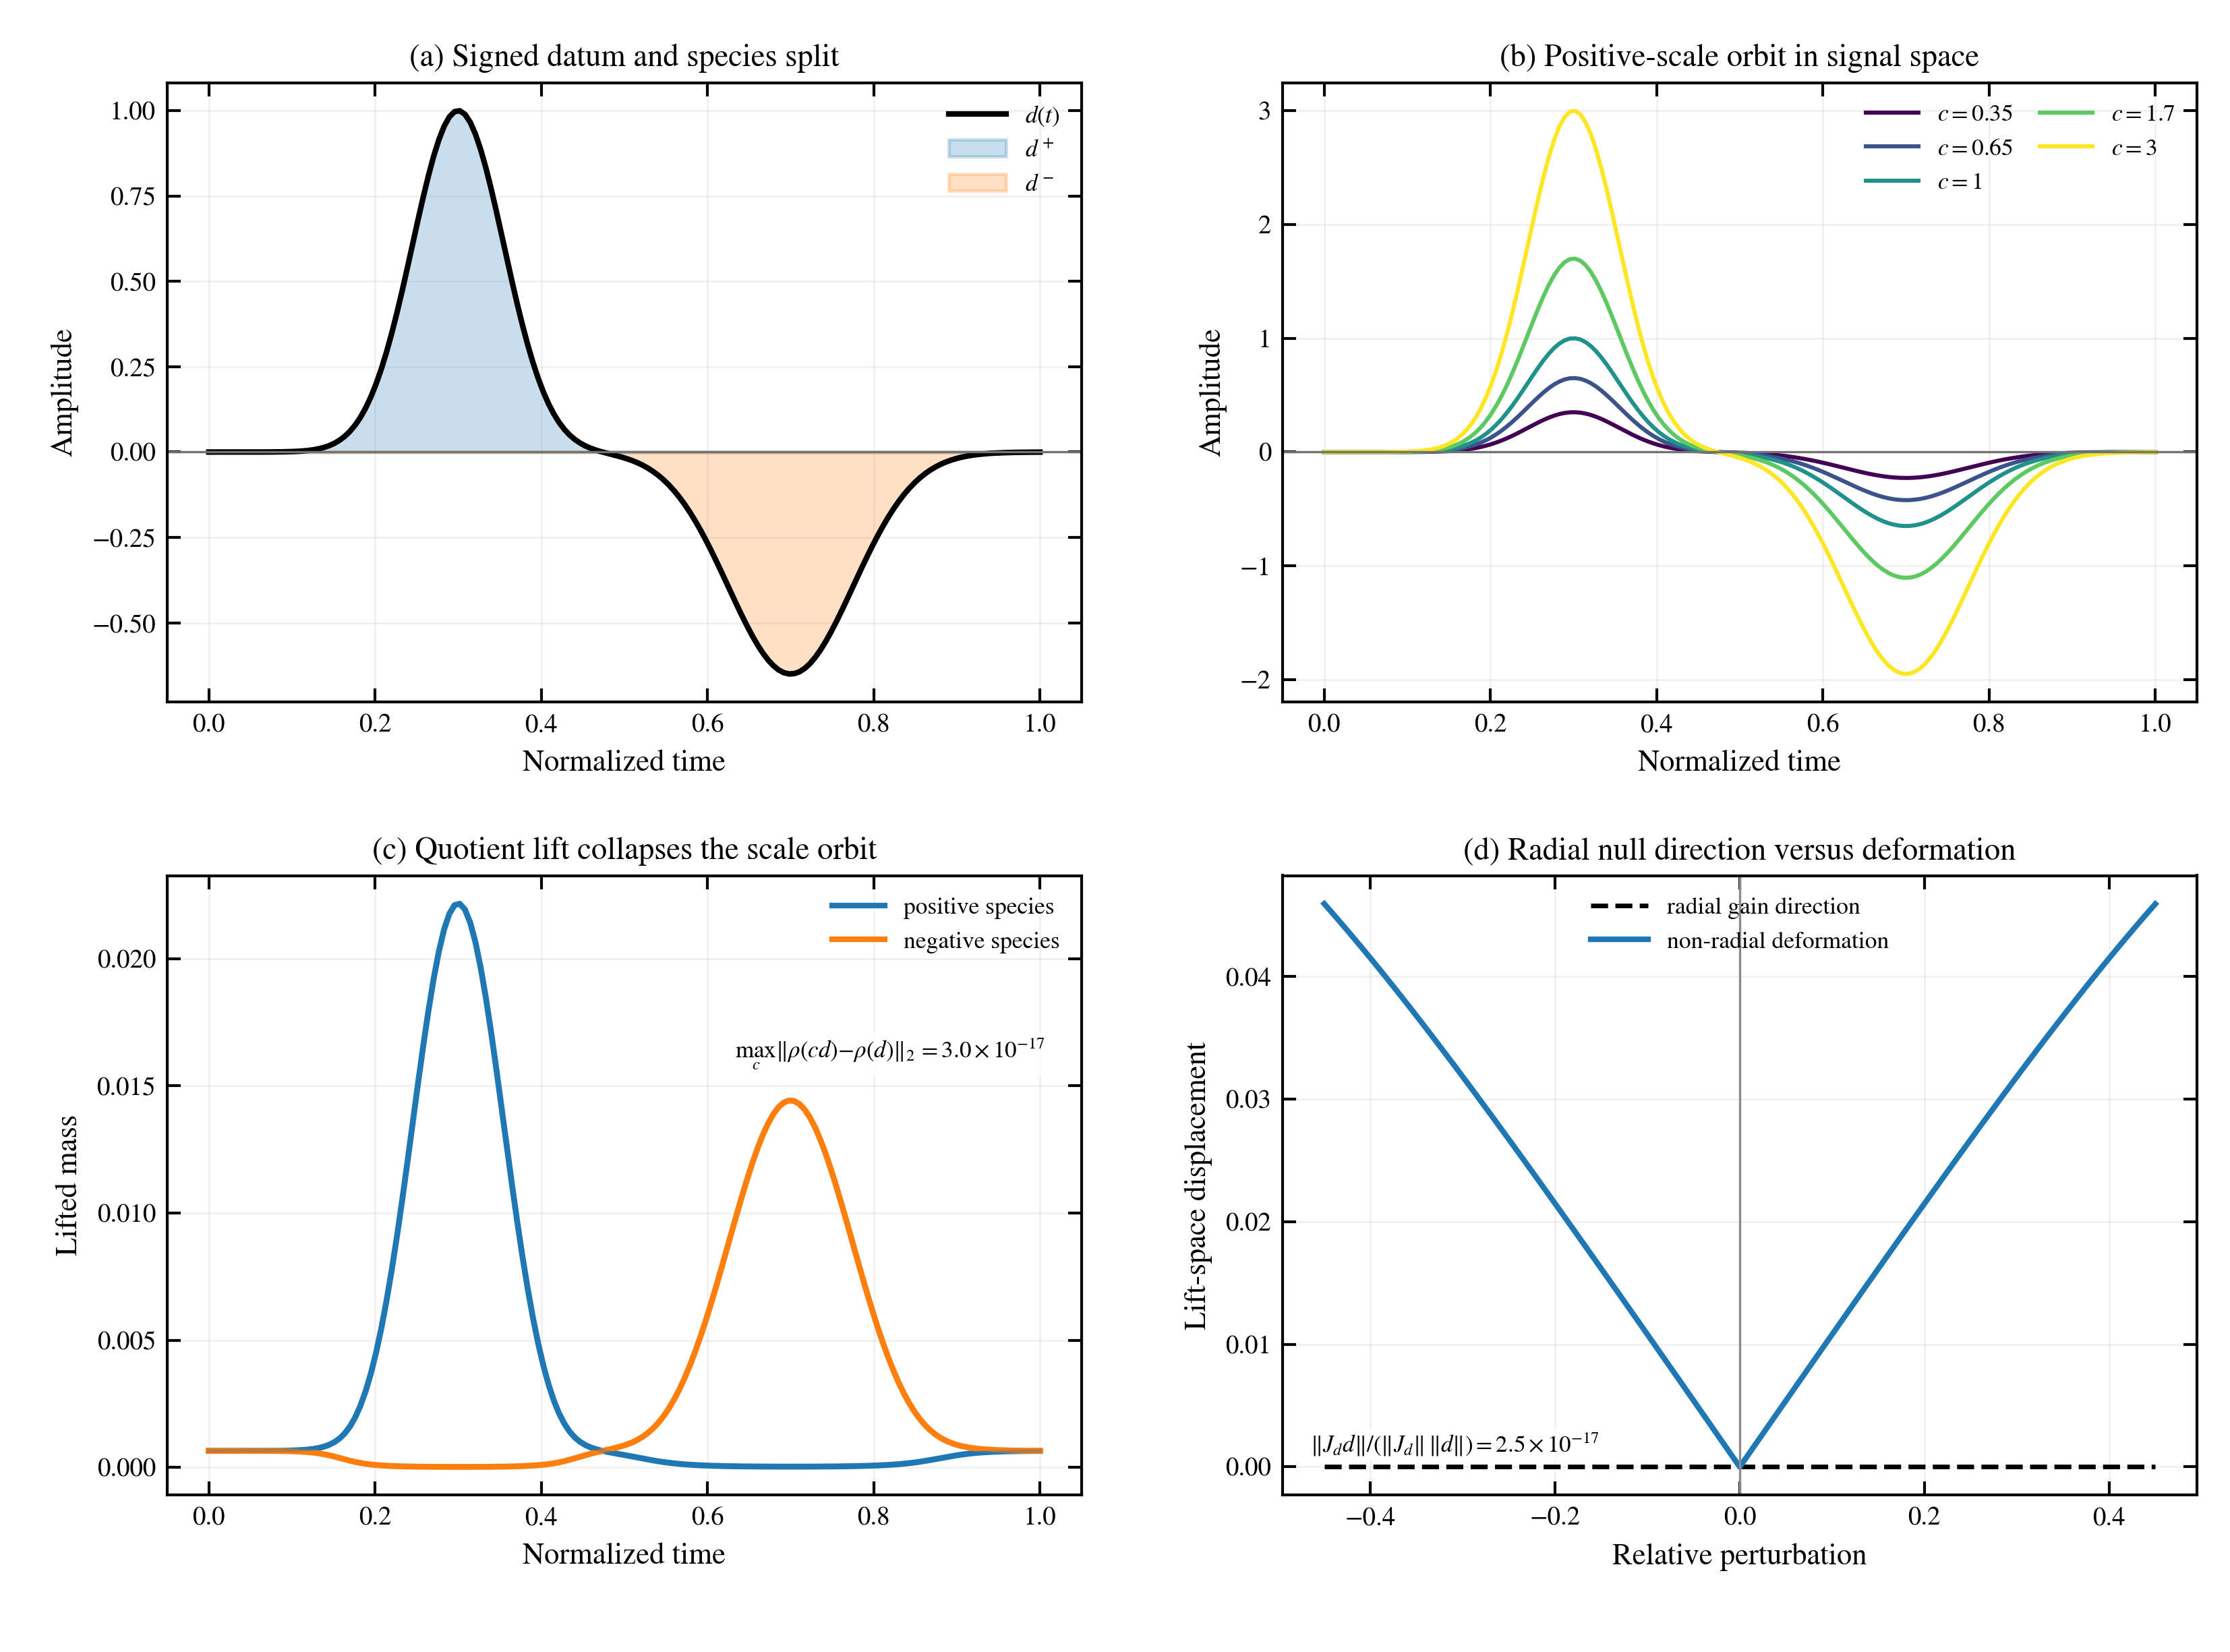

In [13]:
def show_png(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(path)
    display(Image(filename=str(path)))

show_png(ROOT / "experiments/E00/figures/Fig01_geometry_concept.png")